# 01 — Data Exploration (EDA)

**Ziel:** Erstes Verstaendnis des NBA-Datasets aufbauen. Was steckt drin? Wie sauber sind die Daten? Welche Zeitraeume? Welche Features koennten relevant sein?

Dataset: [Historical NBA Data and Player Box Scores (Kaggle)](https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Schoene Defaults fuer Plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Pfad zu den Rohdaten (relativ zum notebooks-Ordner)
DATA_DIR = Path('..') / 'data' / 'raw'
print('Daten-Verzeichnis:', DATA_DIR.resolve())
print('Vorhandene Files:', [f.name for f in DATA_DIR.iterdir()])

Daten-Verzeichnis: C:\Users\Uni\Desktop\Code\nba-game-predictor\data\raw
Vorhandene Files: ['Games.csv', 'LeagueSchedule24_25.csv', 'LeagueSchedule25_26.csv', 'PlayByPlay.parquet', 'Players.csv', 'PlayerStatistics.csv', 'PlayerStatisticsExtended.csv', 'TeamHistories.csv', 'TeamStatistics.csv', 'TeamStatisticsExtended.csv']


## 2. Games.csv laden

Das ist unser Haupt-Dataset: ein Eintrag pro NBA-Spiel mit Heim/Auswaerts-Teams, Scores und Winner.

In [2]:
games = pd.read_csv(DATA_DIR / 'Games.csv', parse_dates=['gameDate'])
print(f'Anzahl Spiele: {len(games):,}')
print(f'Spalten:       {games.shape[1]}')
print(f'Zeitraum:      {games.gameDate.min().date()}  bis  {games.gameDate.max().date()}')
games.head()

C:\Users\Uni\AppData\Local\Temp\ipykernel_32636\2165150526.py:1: DtypeWarning: Columns (0: gameSubtype, 1: gameSubLabel, 2: seriesGameNumber, 3: arenaName, 4: arenaCity, 5: arenaState, 6: officials) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv(DATA_DIR / 'Games.csv', parse_dates=['gameDate'])


Anzahl Spiele: 73,224
Spalten:       23
Zeitraum:      1946-11-26  bis  2026-04-26


,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500174,2026-04-26 21:30:00,Houston,Rockets,1610612745,Los Angeles,Lakers,1610612747,115,96,...,West First Round,Game 4,Game 4,18055.0,215,Toyota Center,Houston,TX,"JB DeRosa, Kevin Scott, James Williams, Nate G...",2026-04-26 21:30:00
1,42500114,2026-04-26 19:00:00,Philadelphia,76ers,1610612755,Boston,Celtics,1610612738,96,128,...,East First Round,Game 4,Game 4,19746.0,1000152,Xfinity Mobile Arena,Philadelphia,PA,"Ed Malloy, Mark Lindsay, Josh Tiven, Mousa Dagher",2026-04-26 19:00:00
2,42500154,2026-04-26 15:30:00,Portland,Trail Blazers,1610612757,San Antonio,Spurs,1610612759,93,114,...,West First Round,Game 4,Game 4,19717.0,51,Moda Center,Portland,OR,"Zach Zarba, Dedric Taylor, Justin Van Duyne, A...",2026-04-26 15:30:00
3,42500134,2026-04-26 13:00:00,Toronto,Raptors,1610612761,Cleveland,Cavaliers,1610612739,93,89,...,East First Round,Game 4,Game 4,19800.0,643,Scotiabank Arena,Toronto,ON,"John Goble, Curtis Blair, Ray Acosta, Natalie ...",2026-04-26 13:00:00
4,42500164,2026-04-25 20:30:00,Minnesota,Timberwolves,1610612750,Denver,Nuggets,1610612743,112,96,...,West First Round,Game 4,Game 4,18978.0,61,Target Center,Minneapolis,MN,"Marc Davis, Pat Fraher, Sean Wright, Jason Gol...",2026-04-25 20:30:00


## 3. Welche Spalten gibt es? Welche Datentypen?

In [3]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 73224 entries, 0 to 73223
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gameId            73224 non-null  int64         
 1   gameDateTimeEst   73224 non-null  str           
 2   hometeamCity      73217 non-null  str           
 3   hometeamName      73224 non-null  str           
 4   hometeamId        73224 non-null  int64         
 5   awayteamCity      73217 non-null  str           
 6   awayteamName      73224 non-null  str           
 7   awayteamId        73224 non-null  int64         
 8   homeScore         73224 non-null  int64         
 9   awayScore         73224 non-null  int64         
 10  winner            73224 non-null  int64         
 11  gameType          73224 non-null  str           
 12  gameSubtype       74 non-null     str           
 13  gameLabel         3988 non-null   str           
 14  gameSubLabel      273 non-null   

## 4. Fehlende Werte (Missing Values)

Wichtig: Welche Spalten haben Luecken? Die muessen wir spaeter behandeln.

In [4]:
missing = games.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(games) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df[missing_df.missing > 0]

,missing,pct
gameSubtype,73150,99.90
gameSubLabel,72951,99.63
arenaState,71888,98.18
attendance,71887,98.17
officials,71879,98.16
arenaCity,71879,98.16
arenaName,71879,98.16
gameLabel,69236,94.55
seriesGameNumber,67456,92.12
hometeamCity,7,0.01


## 5. Spiele pro Saison

Wir erwarten: ~1230 Regular-Season-Spiele pro moderner Saison (30 Teams x 82 Spiele / 2). Frueher weniger Teams = weniger Spiele.

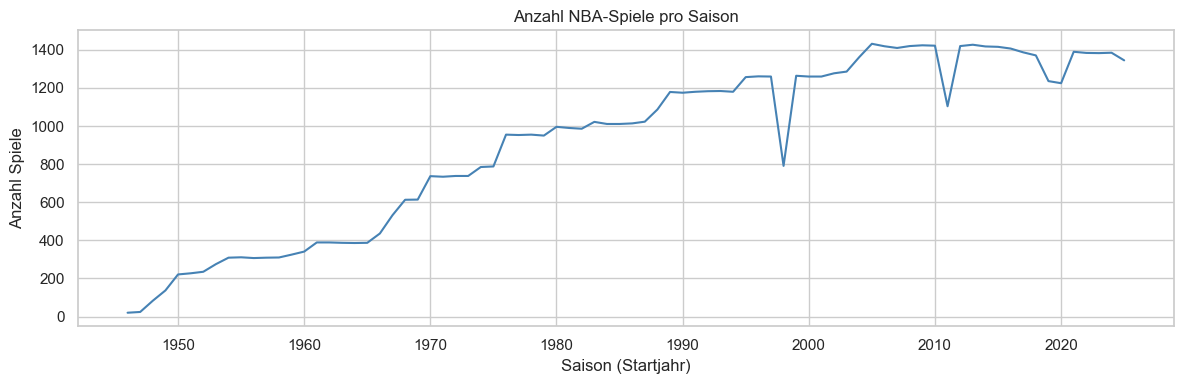

Erste Saison:  1946  (20 Spiele)
Letzte Saison: 2025  (1345 Spiele)


In [5]:
# Saison ableiten: NBA-Saison startet Oktober, endet Juni -> Jahr der Oktober-Haelfte
games['season'] = np.where(
    games.gameDate.dt.month >= 10,
    games.gameDate.dt.year,
    games.gameDate.dt.year - 1
)

games_per_season = games.groupby('season').size()

fig, ax = plt.subplots(figsize=(12, 4))
games_per_season.plot(ax=ax, color='steelblue')
ax.set_title('Anzahl NBA-Spiele pro Saison')
ax.set_xlabel('Saison (Startjahr)')
ax.set_ylabel('Anzahl Spiele')
plt.tight_layout()
plt.show()

print(f'Erste Saison:  {games_per_season.index.min()}  ({games_per_season.iloc[0]} Spiele)')
print(f'Letzte Saison: {games_per_season.index.max()}  ({games_per_season.iloc[-1]} Spiele)')

## 6. Home Advantage — gibt es ihn wirklich?

Klassische Frage: Gewinnen Heimteams oeffter? Das ist das einfachste Baseline-Feature.

In [6]:
# Nur Spiele mit gueltigem Score nehmen
played = games.dropna(subset=['homeScore', 'awayScore']).copy()
played['home_win'] = played.homeScore > played.awayScore

home_win_rate = played.home_win.mean()
print(f'Home-Win-Rate ueber alle Saisons: {home_win_rate:.1%}')
print(f'Anzahl ausgewerteter Spiele:      {len(played):,}')

Home-Win-Rate ueber alle Saisons: 61.6%
Anzahl ausgewerteter Spiele:      73,224


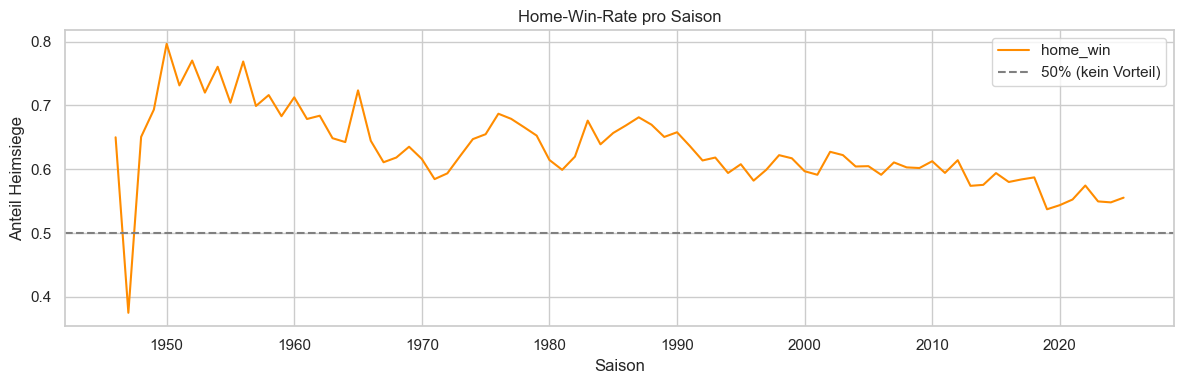

In [7]:
# Home-Win-Rate pro Saison
home_win_by_season = played.groupby('season').home_win.mean()

fig, ax = plt.subplots(figsize=(12, 4))
home_win_by_season.plot(ax=ax, color='darkorange')
ax.axhline(0.5, color='gray', linestyle='--', label='50% (kein Vorteil)')
ax.set_title('Home-Win-Rate pro Saison')
ax.set_xlabel('Saison')
ax.set_ylabel('Anteil Heimsiege')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Score-Verteilung

Wie sehen typische Endstaende aus? Hat sich das Scoring-Niveau ueber die Jahrzehnte veraendert?

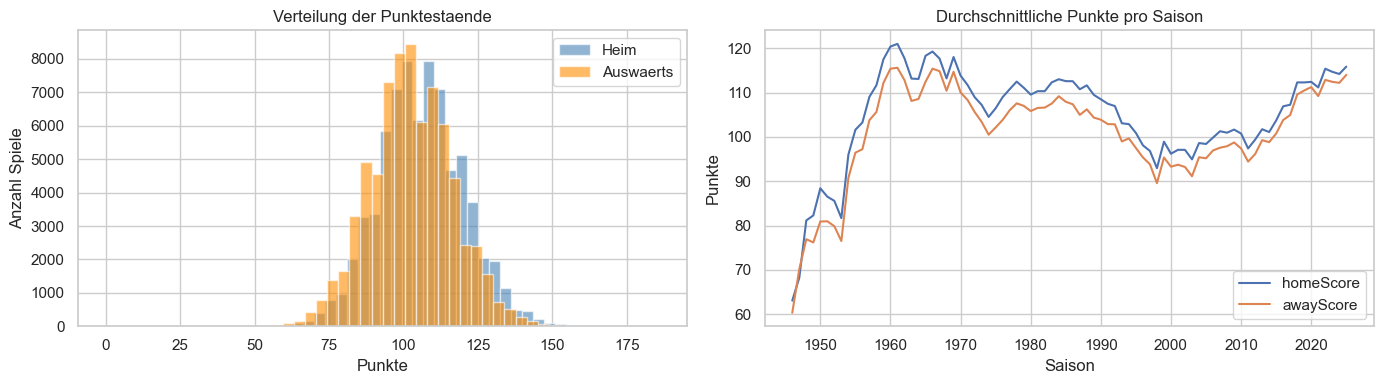

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Verteilung der Endstaende
axes[0].hist(played.homeScore, bins=50, alpha=0.6, label='Heim', color='steelblue')
axes[0].hist(played.awayScore, bins=50, alpha=0.6, label='Auswaerts', color='darkorange')
axes[0].set_title('Verteilung der Punktestaende')
axes[0].set_xlabel('Punkte')
axes[0].set_ylabel('Anzahl Spiele')
axes[0].legend()

# Avg Score pro Saison
avg_score = played.groupby('season')[['homeScore', 'awayScore']].mean()
avg_score.plot(ax=axes[1])
axes[1].set_title('Durchschnittliche Punkte pro Saison')
axes[1].set_xlabel('Saison')
axes[1].set_ylabel('Punkte')

plt.tight_layout()
plt.show()

## 8. Game Types

Wir sollten Regular Season von Playoffs trennen — die Dynamik ist anders.

In [9]:
games.gameType.value_counts(dropna=False)

gameType
Regular Season        66768
Playoffs               4471
Preseason              1873
NBA Emirates Cup         66
Play-in Tournament       37
All-Star Game             7
Emirates NBA Cup          1
NBA Cup                   1
Name: count, dtype: int64

## 9. Erkenntnisse & naechste Schritte

Notiere hier nach dem Durchlaufen:
- Wie viele Spiele insgesamt?
- Wie hoch ist die Home-Win-Rate? (Erwartung: ~58–60%)
- Welche Spalten sind unbrauchbar/zu luecken?
- Welche Saisons sind vollstaendig genug fuer Backtesting?

**Naechstes Notebook:** `02_feature_engineering.ipynb` — Team-Form, ELO-Rating, Head-to-Head.